# Import libaries and load CIFAR-10 Datasets

---



In [119]:
import tarfile
import os
import pickle
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split, TensorDataset
from torch import nn
import torchvision
from torchvision.datasets.utils import download_url
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch.optim as optim

In [120]:
# dowload the dataset
dataset_url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
download_url(dataset_url, '.')

In [121]:
with tarfile.open('cifar-10-python.tar.gz', 'r:gz') as tar:
    tar.extractall(path='./data')

data_dir = './data/cifar-10-batches-py'

print(os.listdir(data_dir))  # expect to see: data_batch_1, ..., test_batch, batches.meta

['batches.meta', 'readme.html', 'data_batch_1', 'data_batch_4', 'data_batch_3', 'data_batch_2', 'test_batch', 'data_batch_5']


In [122]:
def load_batch(file):
    with open(file, 'rb') as f:
        dict = pickle.load(f, encoding='bytes')
        data = dict[b'data']
        labels = dict[b'labels']
        return data, labels

# load and combine training batches
X_train = []
y_train = []

for i in range(1, 6):
    batch_file = os.path.join(data_dir, f'data_batch_{i}')
    data, labels = load_batch(batch_file)
    X_train.append(data)
    y_train.extend(labels)

# combine into a single numpy array
X_train = np.concatenate(X_train)
y_train = np.array(y_train)

# load test batch
test_file = os.path.join(data_dir, 'test_batch')
X_test, y_test = load_batch(test_file)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)


# Split train-valid-test and preprocessing

In [123]:
# reshape data
X_train = X_train.reshape(-1, 3, 32, 32).astype('float32')
X_test = X_test.reshape(-1, 3, 32, 32).astype('float32')

# normalize
X_train /= 255
X_test /= 255

# split validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size = 0.9, random_state = 42)

# convert to pytorch tensors
X_train = torch.from_numpy(X_train)
X_val = torch.from_numpy(X_val)
X_test = torch.from_numpy(X_test)
y_train = torch.from_numpy(y_train)
y_val = torch.from_numpy(y_val)
y_test = torch.from_numpy(y_test)

# create TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# batch_size=128
# train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size*2)

# from torchvision.utils import make_grid

# def show_batch(dl):
#     for images, labels in dl:
#         fig, ax = plt.subplots(figsize=(12, 6))
#         ax.set_xticks([]); ax.set_yticks([])
#         ax.imshow(make_grid(images, nrow=16).permute(1, 2, 0))
#         break

# show_batch(train_loader)

# Creat model


In [124]:
def create_MLP_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # flat data
    nn.Flatten(),

    # hidden layer
    nn.Linear(3072, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(dropout_rate),

    # output layer
    nn.Linear(512, 10)
  )
  return model

def create_CNN_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # CNN-1
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 32 x 16 x 16

    # CNN-2
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 64 x 8 x 8

    # CNN-3
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 128 x 4 x 4

    nn.Flatten(),

    # Dense layer
    nn.Linear(128*4*4, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(dropout_rate),

    # output layer
    nn.Linear(512, 10)
  )
  return model

# Training model

In [125]:
def train_model(model, train_dataset, val_dataset, num_epochs = 10, batch_size = 128, learning_rate = 0.001):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  # create loss function
  loss_fn = nn.CrossEntropyLoss()

  # create optimizer
  optimizer = optim.Adam(model.parameters(), lr = learning_rate)

  # create Dataloader
  train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset, batch_size*2)

  history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
  for epoch in range(num_epochs):
      model.train()  # set model to train mode
      train_loss = 0
      train_correct = 0
      train_total = 0
      # loop through batches
      for X_batch, y_batch in train_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)

          # 1. forward pass
          y_pred = model(X_batch)

          # 2. calculate loss
          loss = loss_fn(y_pred, y_batch)
          train_loss += loss.item()  # accumulate loss

          # 3. optimizer zero grad
          optimizer.zero_grad()

          # 4. backpropagation
          loss.backward()

          # 5. optimizer step
          optimizer.step()

          # calculate accuracy
          preds = torch.argmax(y_pred, dim = 1)
          train_correct += (preds == y_batch).sum().item()
          train_total += y_batch.size(0)

      # validation loop
      model.eval()  # set model to eval mode
      val_loss = 0
      val_correct = 0
      val_total = 0
      with torch.inference_mode():
          for X_batch, y_batch in val_loader:
              X_batch, y_batch = X_batch.to(device), y_batch.to(device)

              y_pred = model(X_batch)
              loss = loss_fn(y_pred, y_batch)
              val_loss += loss.item()

              # calculate accuracy
              preds = torch.argmax(y_pred, dim = 1)
              val_correct += (preds == y_batch).sum().item()
              val_total += y_batch.size(0)

      train_accuracy = train_correct / train_total
      val_accuracy = val_correct / val_total

      history['accuracy'].append(train_accuracy)
      history['val_accuracy'].append(val_accuracy)
      history['loss'].append(train_loss / len(train_loader))
      history['val_loss'].append(val_loss / len(val_loader))
      # print loss and accuracy every epoch
      print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(train_loader):.4f}, "
            f"Val Loss: {val_loss/len(val_loader):.4f}, Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}")
  return history

# Evaluate model and plot learning curve, confusion matrix

In [126]:
def plot_curve(history):
    epochs = range(1, len(history["accuracy"]) + 1)

    plt.figure(figsize = (12, 5))

    # accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["accuracy"], label = "Train Accuracy")
    plt.plot(epochs, history["val_accuracy"], label = "Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    # loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["loss"], label = "Train Loss")
    plt.plot(epochs, history["val_loss"], label = "Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.show()


In [127]:
def evaluate_model(model, test_dataset, batch_size = 128):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device).eval()

  loss_fn = nn.CrossEntropyLoss()
  test_loader = DataLoader(test_dataset, batch_size = batch_size)

  total_loss = 0
  test_correct = 0
  test_total = 0

  with torch.inference_mode():
      for X_batch, y_batch in test_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)

          y_pred = model(X_batch)
          total_loss += loss_fn(y_pred, y_batch).item()

          preds = y_pred.argmax(dim = 1)
          test_correct += (preds == y_batch).sum().item()
          test_total += y_batch.size(0)

  loss = total_loss / len(test_loader)
  acc = test_correct / test_total
  return loss, acc

In [128]:
def plot_matrix(model, test_dataset):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device).eval()
  test_loader = DataLoader(test_dataset, batch_size = 4000)

  y_true = []
  y_pred = []

  with torch.inference_mode():
      for X_batch, y_batch in test_loader:
          X_batch, y_batch = X_batch.to(device), y_batch.to(device)
          y_pred_batch = model(X_batch)
          preds = y_pred_batch.argmax(dim = 1)
          y_true.extend(y_batch.cpu().numpy())
          y_pred.extend(preds.cpu().numpy())

  cm = confusion_matrix(y_true, y_pred)

  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap=plt.cm.Blues)
  plt.title("Confusion Matrix")
  plt.show()

Epoch 1/10, Train Loss: 3.4539, Val Loss: 2.1742, Train Accuracy: 0.1268, Val Accuracy: 0.1800
Epoch 2/10, Train Loss: 2.1032, Val Loss: 1.9996, Train Accuracy: 0.2097, Val Accuracy: 0.2764
Epoch 3/10, Train Loss: 1.9564, Val Loss: 1.9157, Train Accuracy: 0.2817, Val Accuracy: 0.3070
Epoch 4/10, Train Loss: 1.8687, Val Loss: 1.8386, Train Accuracy: 0.3221, Val Accuracy: 0.3336
Epoch 5/10, Train Loss: 1.7958, Val Loss: 1.8009, Train Accuracy: 0.3510, Val Accuracy: 0.3580
Epoch 6/10, Train Loss: 1.7605, Val Loss: 1.7618, Train Accuracy: 0.3662, Val Accuracy: 0.3584
Epoch 7/10, Train Loss: 1.7168, Val Loss: 1.7121, Train Accuracy: 0.3842, Val Accuracy: 0.3734
Epoch 8/10, Train Loss: 1.6850, Val Loss: 1.7026, Train Accuracy: 0.3914, Val Accuracy: 0.3856
Epoch 9/10, Train Loss: 1.6657, Val Loss: 1.6572, Train Accuracy: 0.4036, Val Accuracy: 0.4050
Epoch 10/10, Train Loss: 1.6513, Val Loss: 1.6428, Train Accuracy: 0.4129, Val Accuracy: 0.4074


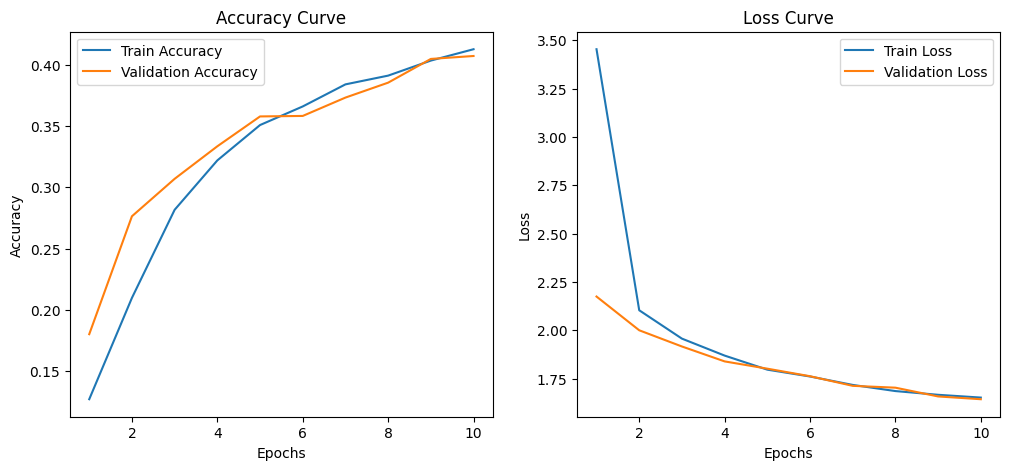

Test Loss: 1.6203, Test Accuracy: 0.4241


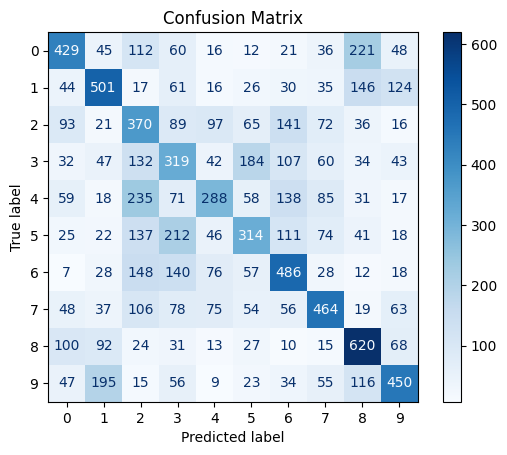

In [129]:
model = create_MLP_model()
history = train_model(model, train_dataset, val_dataset, num_epochs = 10, batch_size = 4000, learning_rate = 0.003)
plot_curve(history)
test_loss, test_acc = evaluate_model(model, test_dataset, batch_size = 4000)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

plot_matrix(model, test_dataset)

Epoch 1/10, Train Loss: 2.2814, Val Loss: 2.2161, Train Accuracy: 0.1452, Val Accuracy: 0.1988
Epoch 2/10, Train Loss: 2.1631, Val Loss: 2.0339, Train Accuracy: 0.2074, Val Accuracy: 0.2292
Epoch 3/10, Train Loss: 1.9658, Val Loss: 1.9262, Train Accuracy: 0.2558, Val Accuracy: 0.2898
Epoch 4/10, Train Loss: 1.8335, Val Loss: 1.7619, Train Accuracy: 0.3142, Val Accuracy: 0.3332
Epoch 5/10, Train Loss: 1.6792, Val Loss: 1.6025, Train Accuracy: 0.3693, Val Accuracy: 0.3882
Epoch 6/10, Train Loss: 1.5603, Val Loss: 1.5603, Train Accuracy: 0.4169, Val Accuracy: 0.4186
Epoch 7/10, Train Loss: 1.4734, Val Loss: 1.4146, Train Accuracy: 0.4531, Val Accuracy: 0.4664
Epoch 8/10, Train Loss: 1.4660, Val Loss: 1.4577, Train Accuracy: 0.4600, Val Accuracy: 0.4608
Epoch 9/10, Train Loss: 1.3809, Val Loss: 1.3298, Train Accuracy: 0.4901, Val Accuracy: 0.5138
Epoch 10/10, Train Loss: 1.3143, Val Loss: 1.3401, Train Accuracy: 0.5186, Val Accuracy: 0.5118


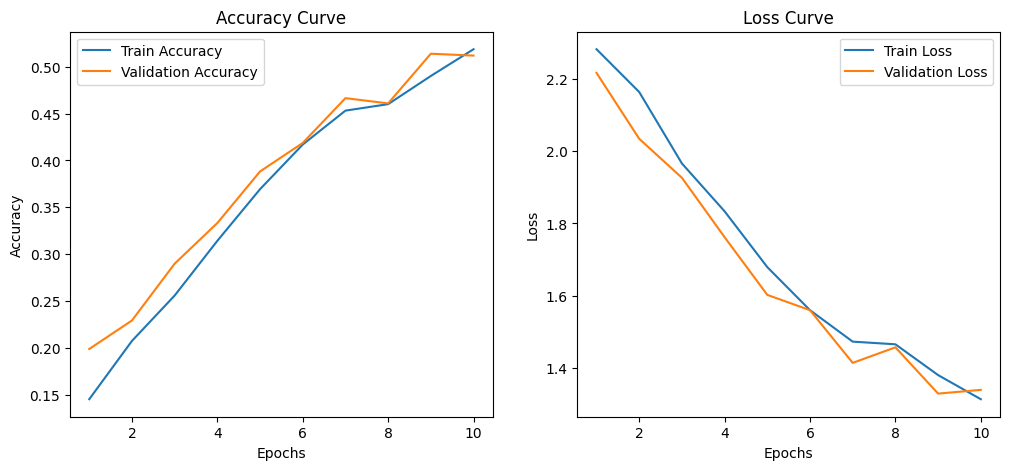

Test Loss: 1.3331, Test Accuracy: 0.5168


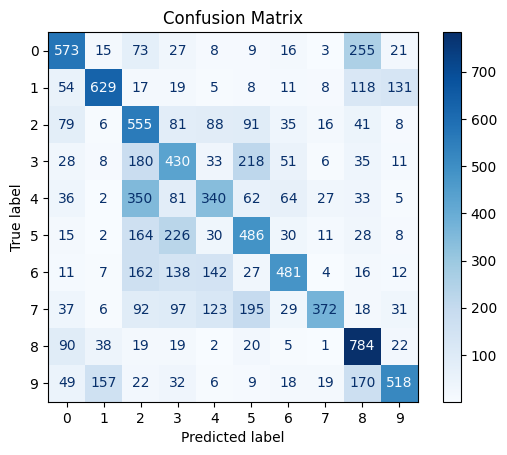

In [130]:
model = create_CNN_model()
history = train_model(model, train_dataset, val_dataset, num_epochs = 10, batch_size = 4000, learning_rate = 0.003)
plot_curve(history)
test_loss, test_acc = evaluate_model(model, test_dataset, batch_size = 4000)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

plot_matrix(model, test_dataset)